## Initialization

In [72]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision_cp_sectors
importlib.reload(collision_cp_sectors)
from collision_cp_sectors import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [39]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06


In [431]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print("mean spacing (beta)", mean_spacing)
rrkm_beta = 2 * np.pi / mean_spacing
observed_beta = 2 * np.pi / mean_spacing * 1e5
print("RRKM (tau beta)", 2 * np.pi / mean_spacing)
print("measured (tau beta)", 2 * np.pi / mean_spacing * 1e5)

# thermal properties
temp = 0.01         # in terms of E6
num_resonances = 10        # should be odd
print(mean_spacing / temp)

mean spacing (beta) 274.16760284403034
RRKM (tau beta) 0.02291731496355531
measured (tau beta) 2291.731496355531
27416.760284403033


In [262]:
hbar = 1
std_k = np.sqrt(temp) / 5
std_x = 1 / std_k
print(std_x)
x0 = 100
k0 = np.sqrt(temp)
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

50.0
1000.0


In [41]:
length = 2 # cutoff distance (in beta)

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
sector_coupling_strength = mean_coupling_strength / 10
num_sectors = 1
# find positive time delay

def get_spectrum():
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength, sector_coupling_strength, num_sectors=num_sectors)
    return energy_GOE_mat, W_mat, x_actual

energy_GOE_mat, W_mat, x_actual = get_spectrum()

(array([  2.,   0.,   4.,   3.,   4.,  16.,  20.,  35.,  57.,  93., 173.,
        253., 150.,  87.,  47.,  24.,  16.,   9.,   5.,   2.]),
 array([-8.72652494, -7.95683815, -7.18715137, -6.41746458, -5.64777779,
        -4.878091  , -4.10840422, -3.33871743, -2.56903064, -1.79934385,
        -1.02965707, -0.25997028,  0.50971651,  1.2794033 ,  2.04909008,
         2.81877687,  3.58846366,  4.35815045,  5.12783723,  5.89752402,
         6.66721081]),
 <BarContainer object of 20 artists>)

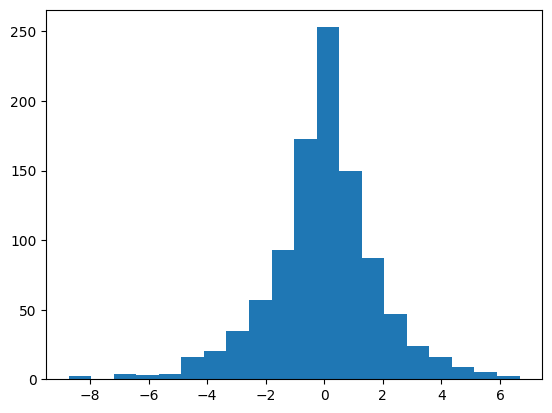

In [509]:
energies = []
for i in range(1000):
    energy_GOE_mat, W_mat, x_actual = get_spectrum()

    args = np.argsort(np.abs(energy_GOE_mat))
    energies.append(energy_GOE_mat[args[0]])
energies = np.array(energies)

plt.hist(energies.get(), bins=20)
# plt.xlim((-mean_spacing, mean_spacing))

## Spectrum

5.2705773911915506
0
[0.64254526 0.97930584]
[0.16861171 1.04445221]
(999,)


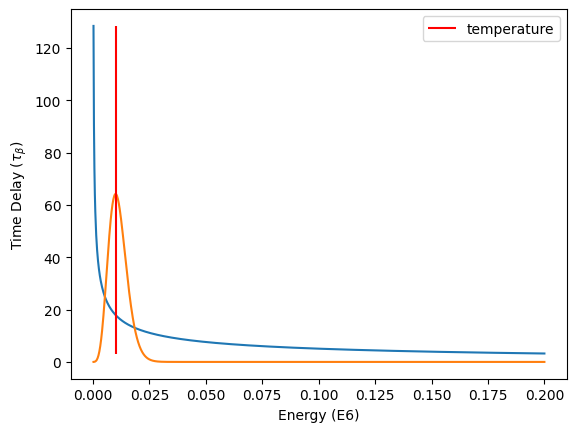

In [481]:
# num_sectors = 100
np.set_printoptions(suppress=True)
count = 0
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
print(mean_coupling_strength)
num_sectors = 100
sector_coupling_strength = mean_coupling_strength / 10
while True:
    energy_GOE_mat, W_mat, x_actual = get_spectrum()
    args = np.argsort(np.abs(energy_GOE_mat))
    if np.abs(energy_GOE_mat[args[0]]) < 20 * temp or True:
        break
    count += 1
print(count)
print(energy_GOE_mat[args[0:2]])
print(W_mat[args[0:2]])

energy_grid = np.linspace(0, 20 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_\beta$)")
plt.savefig("RbCs/wavepacket/spread.pdf")
plt.show()

In [448]:
print(thermal_time_delay(temp, energy_GOE_mat, W_mat, 1000))

-3.500208420610731


In [370]:
thermal_delays = []
for i in range(1000):
    energy_GOE_mat, W_mat, x_actual = get_spectrum()
    thermal_delays.append(thermal_time_delay(temp, energy_GOE_mat, W_mat, 1000).get())

In [ ]:
print(thermal_delays)

[array(-0.23911625), array(0.86516196), array(-0.55056923), array(2.48399342), array(1.14457727), array(-6.22089046), array(0.52288628), array(-0.86815512), array(-0.58785297), array(-0.09613309), array(-0.50934452), array(-0.36978485), array(0.16318788), array(3.21737831), array(0.16883729), array(0.06210732), array(-1.3802861), array(0.1803931), array(0.23815171), array(1.79810599), array(0.95784657), array(-15.47704089), array(0.7220503), array(-0.34618993), array(1.65378925), array(-14.06554899), array(0.23111506), array(0.17157027), array(1.31125362), array(0.49821552), array(1.69942415), array(0.11663281), array(-0.60130667), array(-1.77340064), array(-2.48413864), array(0.43399063), array(0.06051024), array(1.41791169), array(0.01262819), array(-0.05003354), array(0.23365433), array(-1.12633777), array(-0.3937623), array(-0.00324266), array(-3.63313281), array(0.12754492), array(0.62298274), array(-0.06439892), array(0.02098047), array(0.59747431), array(4.38549404), array(0.787

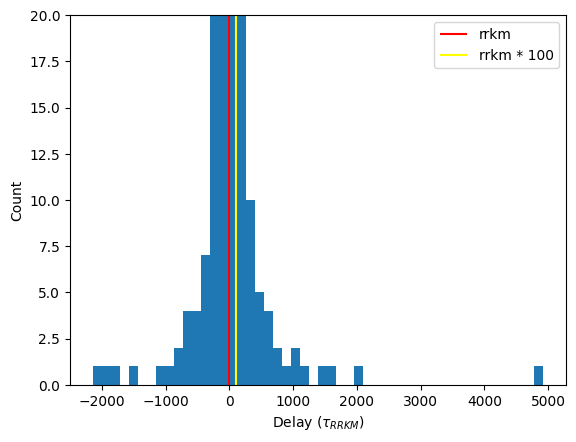

258.97266481324215


In [508]:
plt.hist(np.array(thermal_delays).get() / rrkm_beta, bins=50)
plt.ylim(0, 20)
plt.vlines(1, 0, 100, colors="red", label="rrkm")
plt.vlines(100, 0, 100, colors="yellow", label="rrkm * 100")
plt.ylabel("Count")
plt.xlabel(r"Delay ($\tau_{RRKM}$)")
plt.legend()
plt.show()
print(np.std(np.array(thermal_delays)) / rrkm_beta)

## Wavepacket

In [491]:
import pickle 

data = {}

for sectors in [10]:
    # num_sectors = sectors

    # xs = np.linspace(200, 2200, 2000)
    # dx = xs[1] - xs[0]
    # index = (xs > 100).argmax().item()

    # ps = np.round(np.linspace(k0 - 6 * std_k, k0 + 6 * std_k, 3001), 15)
    # dp = ps[1] - ps[0]
    # ps = ps.reshape((len(ps), 1))

    # maxt = (500 / k0 / 2) * 2
    # ts = np.linspace(0, maxt, 1000)
    # dt = ts[1] - ts[0]
    # time_min = 0
    # # print(time_min)

    # r1 = lambda k : np.exp(-1j * 2 * k * length) #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
    # psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

    # flux_nores = np.sum(np.abs(psi1) ** 2 * dx, axis=1).get()
    
    fluxes = []
    for i in range(100):
        energy_GOE_mat, W_mat, x_actual = get_spectrum()

        r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
        psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])

        flux = np.sum(np.abs(psi2) ** 2 * dx, axis=1).get()

        fluxes.append(flux)

    save_dict = {"fluxes" : fluxes, "flux_nores" : flux_nores}
    data[sectors] = save_dict
    # break
    
    with open("RbKRb/sectors/data_2.pkl", "wb") as f:
        pickle.dump(data, f)

# print(data)

In [ ]:
with open("RbKRb/sectors/data.pkl", "rb") as f:
    fluxes = pickle.load(f)

1575.4148006042296 1583.4285077320212 -8.013707127791577


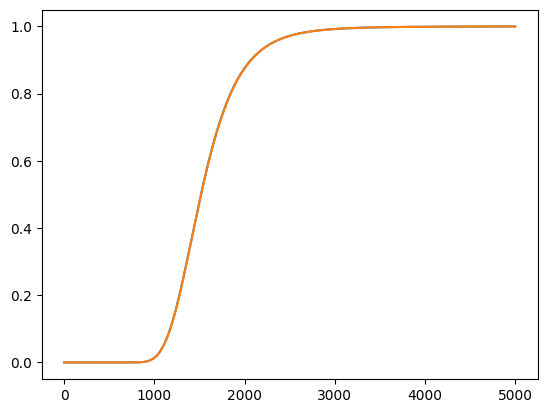

In [492]:
flux = fluxes[0]
plt.plot(ts.get(), flux)
plt.plot(ts.get(), flux_nores)

diff_nores = 0
for i in range(len(flux_nores) - 1):
    diff_nores += (flux_nores[i + 1] - flux_nores[i]) * ts.get()[i]

wavepacket_delays = []
for flux in fluxes:
    diff = 0
    for i in range(len(flux) - 1):
        diff += (flux[i + 1] - flux[i]) * ts.get()[i]
    wavepacket_delays.append(diff - diff_nores)

print(diff, diff_nores, diff - diff_nores)


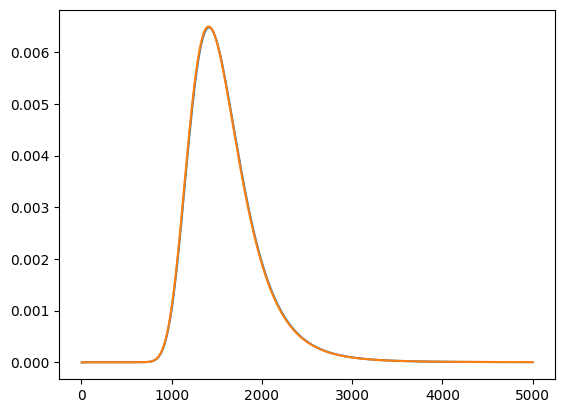

In [487]:
nores_pdf = []
for i in range(len(flux_nores) - 1):
    nores_pdf.append(flux_nores[i + 1] - flux_nores[i])

res_pdf = []
for i in range(len(flux_nores) - 1):
    res_pdf.append(flux[i + 1] - flux[i])

plt.plot(ts.get()[1:], nores_pdf)
plt.plot(ts.get()[1:], res_pdf)

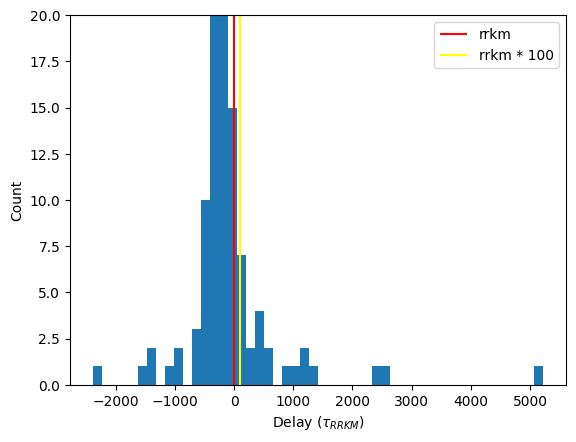

829.7783864500071


In [507]:
plt.hist(np.array(wavepacket_delays).get() / rrkm_beta, bins=50)
plt.ylim(0, 20)
plt.vlines(1, 0, 100, colors="red", label="rrkm")
plt.vlines(109, 0, 100, colors="yellow", label="rrkm * 100")
plt.ylabel("Count")
plt.xlabel(r"Delay ($\tau_{RRKM}$)")
plt.legend()
plt.show()
print(np.std(np.array(wavepacket_delays)) / rrkm_beta)

In [329]:
k0 = np.sqrt(temp)
x0 = 100
print(k0, std_k, x0, std_x)

xs = np.linspace(200, 2200, 2000)
dx = xs[1] - xs[0]
index = (xs > 100).argmax().item()

ps = np.round(np.linspace(k0 - 6 * std_k, k0 + 6 * std_k, 3001), 15)
dp = ps[1] - ps[0]
ps = ps.reshape((len(ps), 1))

maxt = (500 / k0 / 2) * 2
ts = np.linspace(0, maxt, 1000)

psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

0.1 0.02 100 50.0


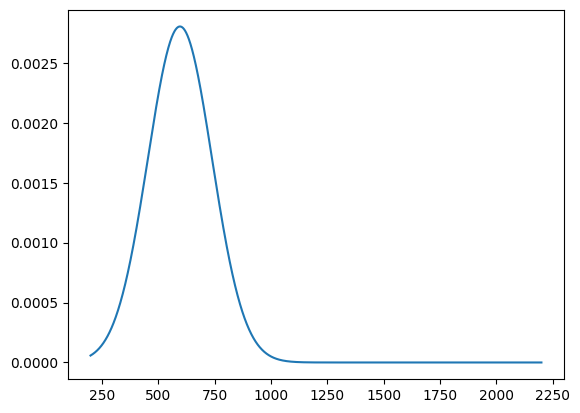

In [330]:
plt.plot(xs.get(), (np.abs(psi1[700]) ** 2 * dx).get())
# plt.xlim(200, 500)

In [144]:
import pickle 
with open("NaK/sectors/sweeep_sectors_fixed.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())

dict_keys([1, 3, 5, 7, 9])


0.9302536709008253
349.5242882661233
Expected 347.09799847990854
Lag 349.5242882661233
Delay -2.4262897862147383


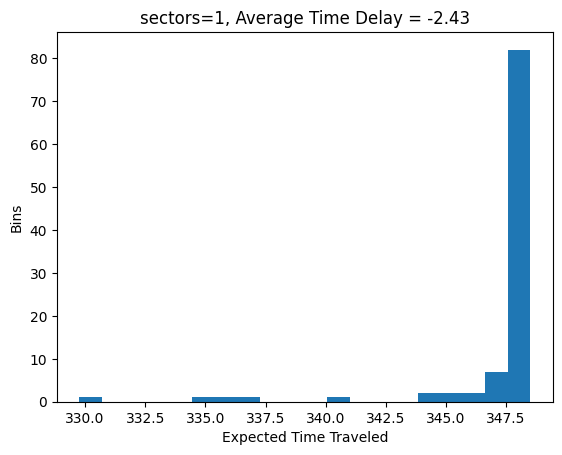

0.9245065985622439
349.5242882661233
Expected 345.7250879624659
Lag 349.5242882661233
Delay -3.799200303657358


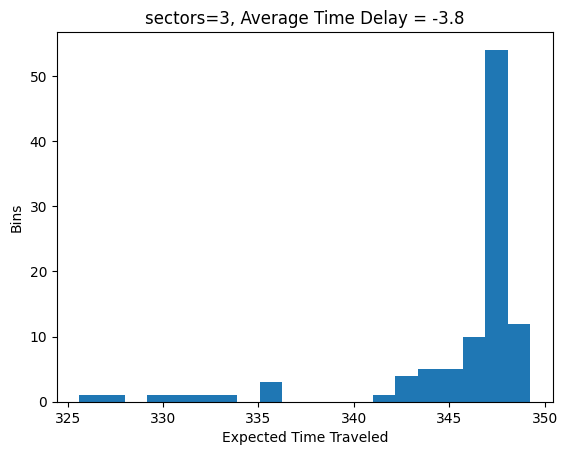

0.8876520434764439
349.5242882661233
Expected 343.4299027703371
Lag 349.5242882661233
Delay -6.0943854957861845


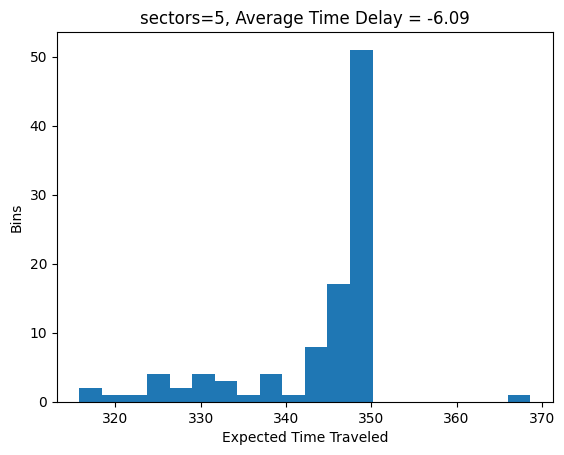

0.8972279084805119
349.5242882661233
Expected 343.9338815811672
Lag 349.5242882661233
Delay -5.590406684956065


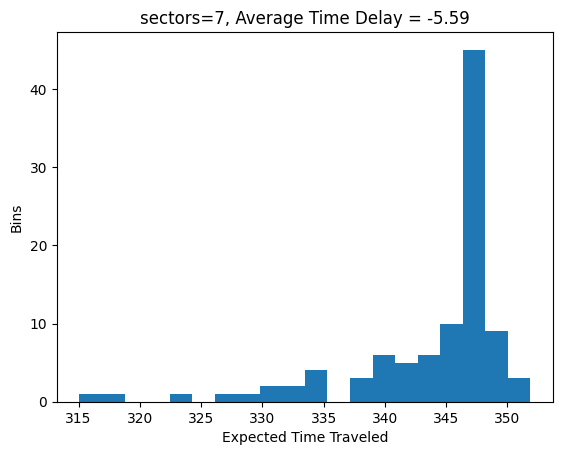

0.7947085234296746
349.5242882661233
Expected 339.9395087402115
Lag 349.5242882661233
Delay -9.584779525911756


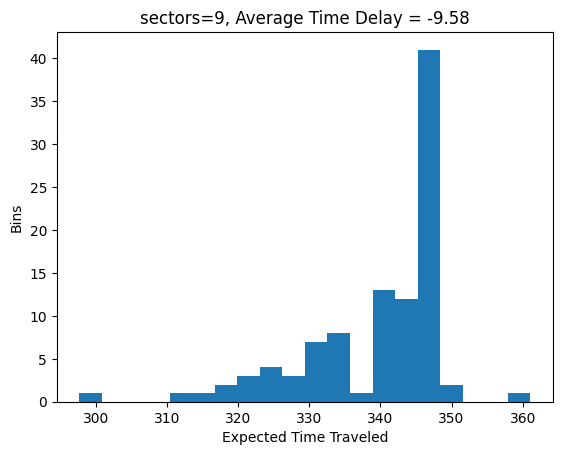

In [148]:
for key in data:
    expected_delay = np.array(data[key]["expected value"])
    # print(expected_delay)
    total_percentage = data[key]["percentage"]
    print(min(total_percentage))

    speed = key
    lag = np.mean(np.array(data[key]["nores"]))
    print(data[key]["nores"])
    print("Expected", np.mean(expected_delay))
    print("Lag", lag)
    print("Delay", np.mean(expected_delay) - lag)
    plt.hist(expected_delay.get(), bins=20)
    plt.xlabel("Expected Time Traveled")
    plt.ylabel("Bins")
    plt.title(f"sectors={round(key, 2)}, Average Time Delay = {round((np.mean(expected_delay) - lag).item(), 2)}")
    plt.savefig(f"RbCs/wavepacket/hist_{round(key, 2)}.pdf")
    plt.show()

## Together

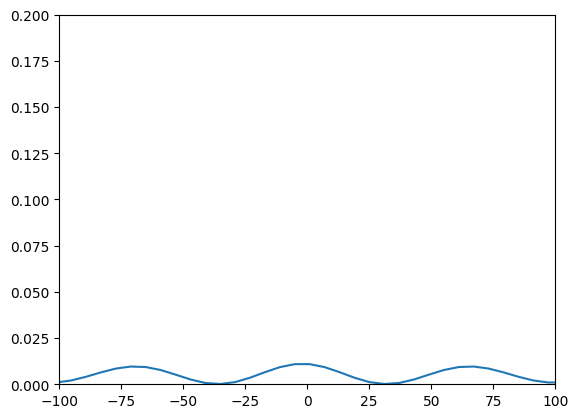

In [249]:
psis = [psi1]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 1
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani

## Animation 2

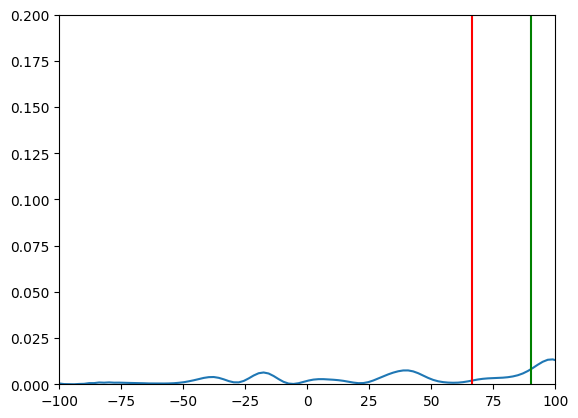

In [287]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi2[i]).get() ** 2)[0]
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
line2 = ax.plot([mean2[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean2_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi2[i]).get() ** 2)
    line2.set_xdata([mean2[i].get() for j in range(num)])
    line3.set_xdata([mean2_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=25, interval=30)
ani

## Animation 1

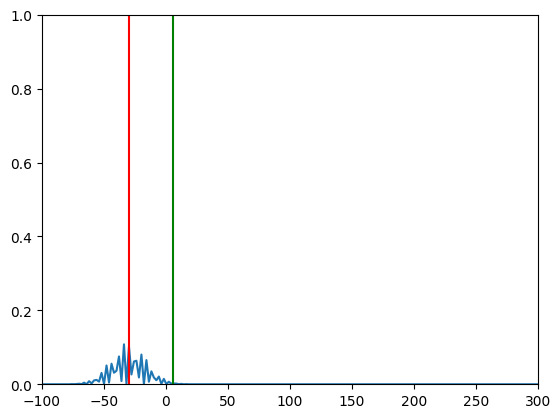

In [274]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi1[i]).get() ** 2)[0]
ax.set(xlim=[-100, 300], ylim=[0, 1])

num = 1000
line2 = ax.plot([mean1[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean1_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi1[i]).get() ** 2)
    line2.set_xdata([mean1[i].get() for j in range(num)])
    line3.set_xdata([mean1_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani